In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
df.shape

(32581, 12)

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [10]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [11]:
df.head()
df['loan_status'].unique()
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

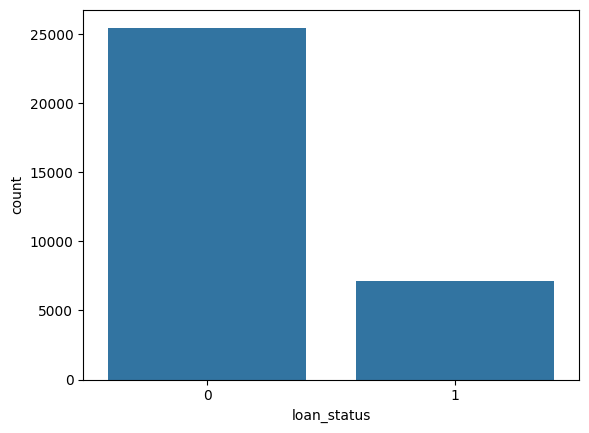

In [12]:
sns.countplot(x='loan_status', data=df)

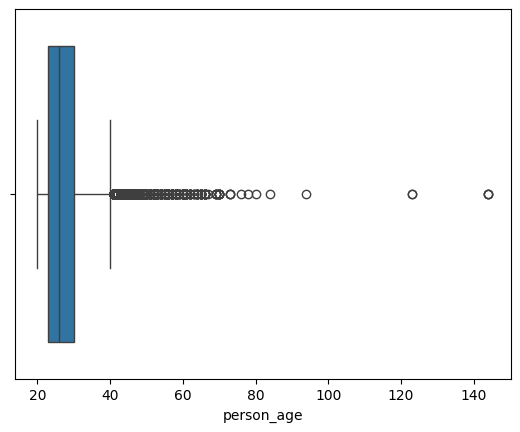

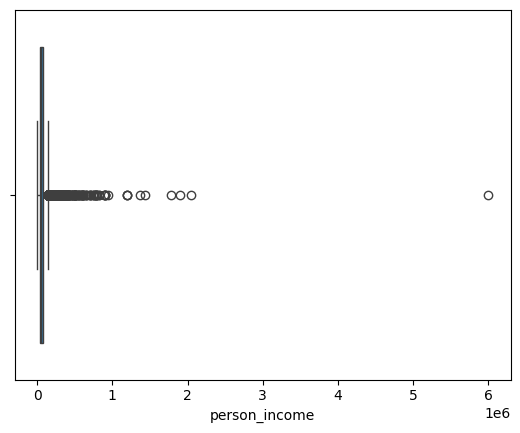

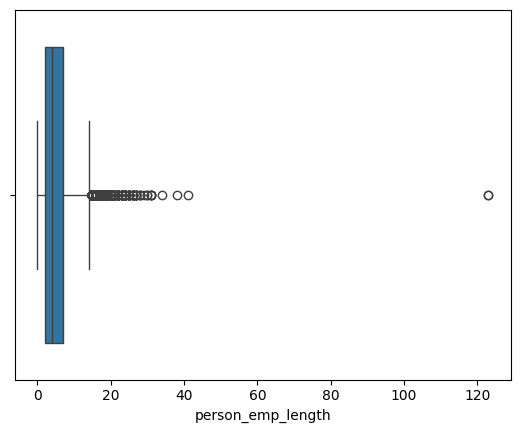

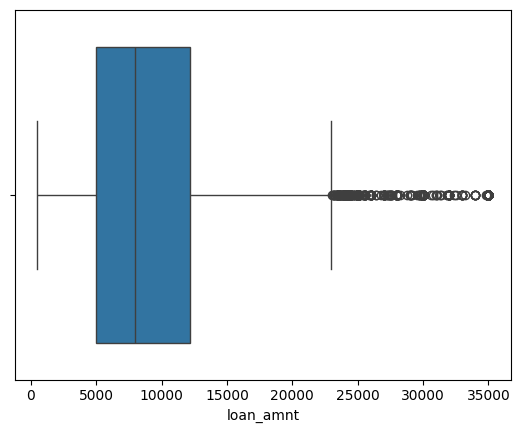

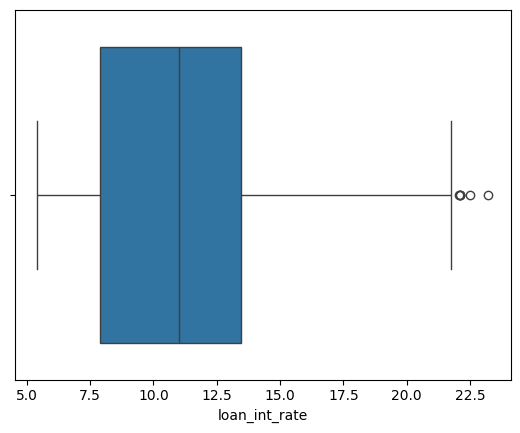

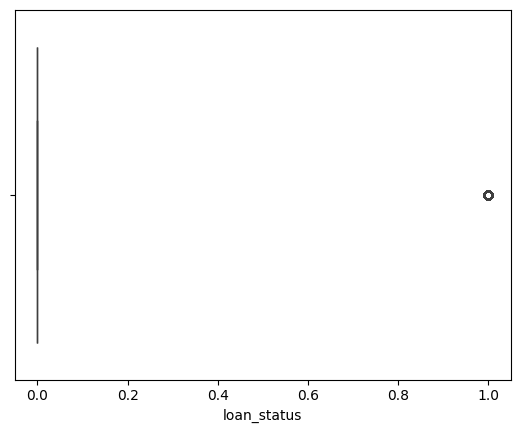

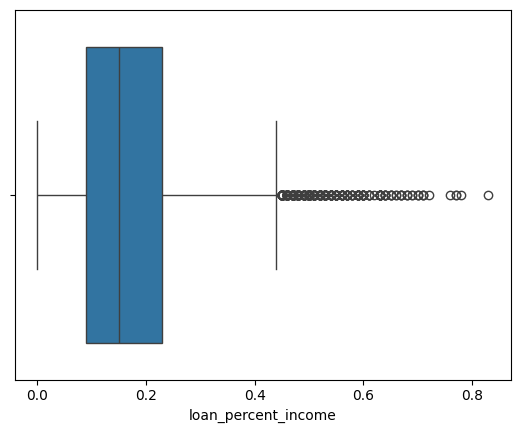

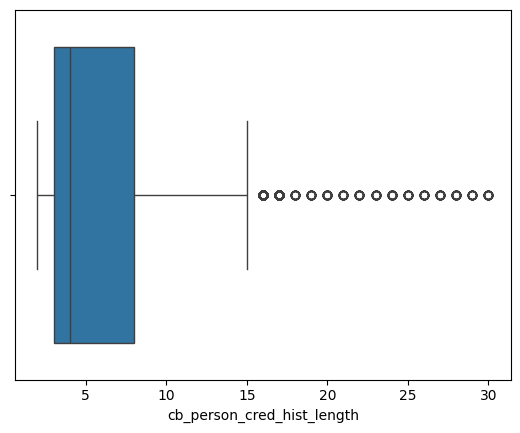

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns

for i in numerical_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [14]:
(df['person_age'] > 100).sum()

np.int64(5)

In [15]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

In [16]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

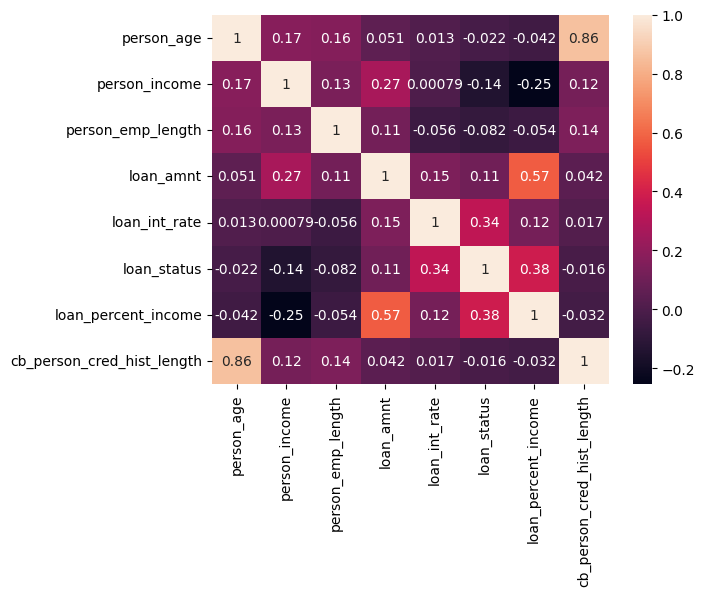

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [18]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

#Remove Duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates : {df_copy.shape[0]}")

#Remove ages below 18 or below 100
df_copy = df_copy[df_copy['person_age'] >=18]
df_copy = df_copy[df_copy['person_age'] <=100]

#Remove employment length greater than age or extreme outliers (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

#Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

#check if the interest rate looks realistic.
print("Loan intreset rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates : 32416
Loan intreset rate range from (min: 5.42 and max: 23.22)


In [19]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status'] #1, 0

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [23]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']



In [24]:
neg, pos = np.bincount(y_train)
scale_weigths = neg/pos

In [25]:
scale_weigths

np.float64(3.6312213039485766)

In [26]:
#Logistic Regression : impute + SCALE Numeric, impute + One-Hot-Encoding
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [27]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [28]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}


In [30]:
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [31]:
import pip
!pip install xgboost
#XGboost Model
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42
    ))
])

In [32]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:

                      cv_results = cross_validate(pipe, X_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

                      print(cv_name)
                      print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
                      print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
                      print(f"Precision : {cv_results['test_precision'].mean()}")
                      print(f"Recall : {cv_results['test_recall'].mean()}")
                      print(f"F1 : {cv_results['test_f1'].mean()}")
                      print()


Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

XGBoost
ROC-AUC : 0.9393848243386111
Accuracy : 0.9086724038455642
Precision : 0.7913354492271174
Recall : 0.7856749311294765
F1 : 0.7880291923045915



In [33]:
from sklearn.pipeline import Pipeline
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight= "balanced"))
])
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



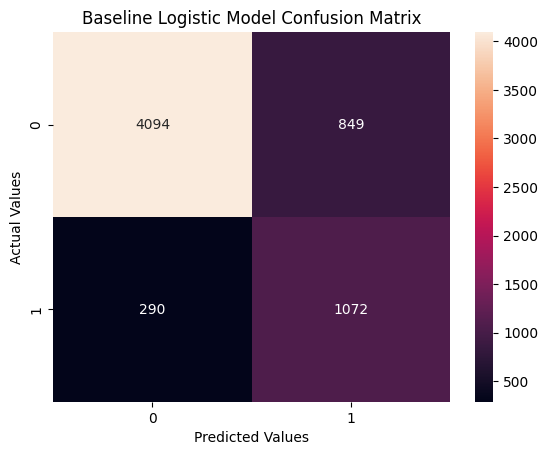

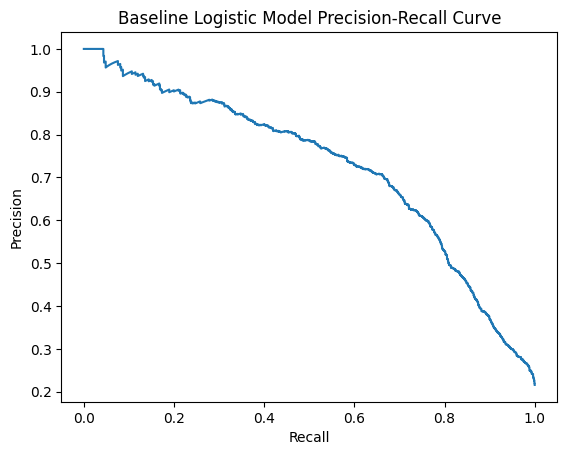

In [34]:
evaluate_model("Baseline Logistic Model", baseline_model ,X_test, y_test)

In [35]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting


random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79a9e01cee90>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79a9de0c7e00>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79a9e01cefd0>},
                   scoring='average_precision', verbose=1)

In [37]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


In [38]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.9984860716796784),
 'classifier__gamma': np.float64(0.16020466731410332),
 'classifier__learning_rate': np.float64(0.04541359612462919),
 'classifier__max_depth': 6,
 'classifier__min_child_weight': 9,
 'classifier__n_estimators': 448,
 'classifier__subsample': np.float64(0.9912720401264106)}

Logistic Regression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



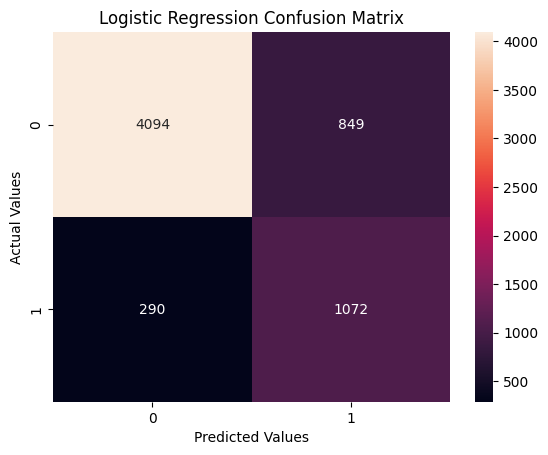

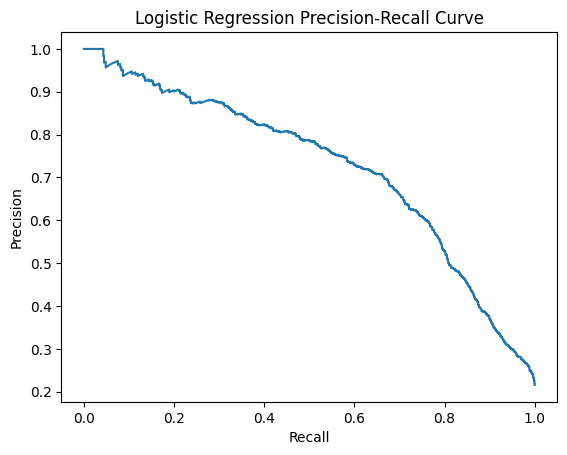

In [39]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)


XGBoost Metrics:
Accuracy : 0.92
Precision : 0.82
Recall : 0.81
F1 : 0.81

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



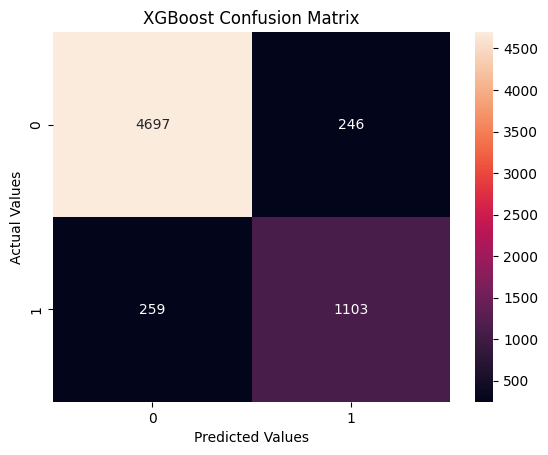

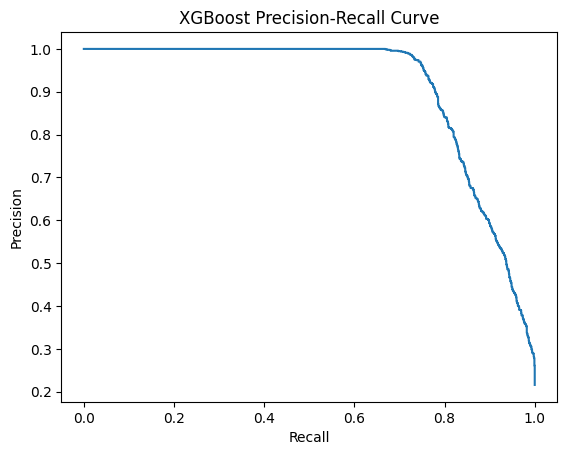

In [40]:
evaluate_model("XGBoost", random_search, X_test, y_test)


XGBoost Metrics:
Used Threshold : 1.00
Accuracy : 0.78
Precision : 0.00
Recall : 0.00
F1 : 0.00

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4943
           1       0.00      0.00      0.00      1362

    accuracy                           0.78      6305
   macro avg       0.39      0.50      0.44      6305
weighted avg       0.61      0.78      0.69      6305



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

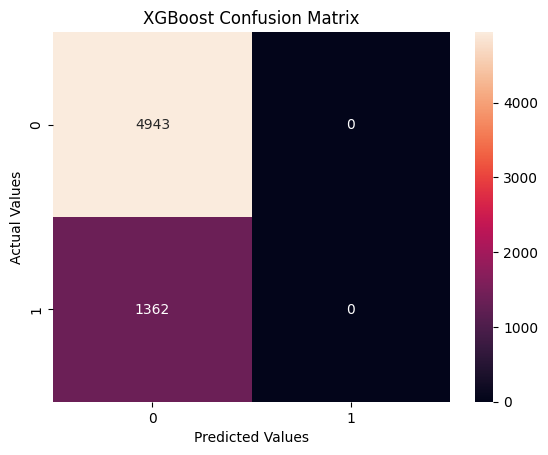

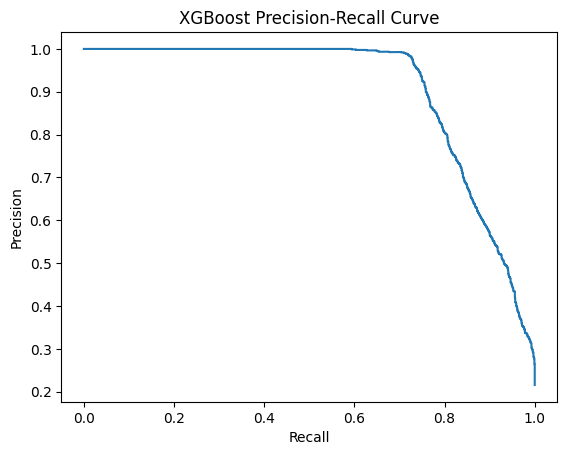

In [41]:
#Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

#For each threshold calculate Precision and Recall
precisions, recalls , thresholds = precision_recall_curve(y_test, prob)


#Calculate F1 score for each threshold
f1 = 2 * (precisions-recalls) / (precisions + recalls + 1e-9)

#Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

#Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

In [42]:
#1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.04541359612462919),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=9,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=448,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [43]:
#2. Get probabilites
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [44]:
#3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)


In [45]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)


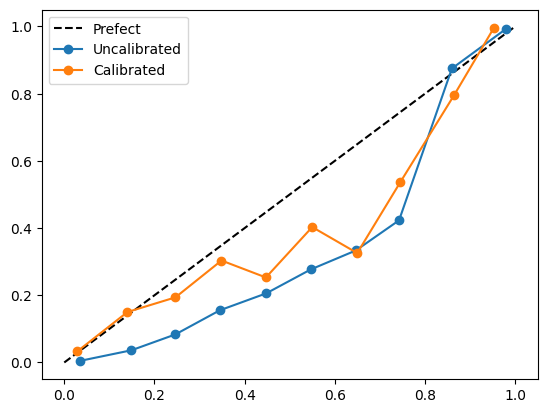

In [46]:

#4. plot
plt.plot([0,1], [0,1], 'k--', label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label = "Calibrated"
)
plt.legend()

In [47]:
#1. Install SHAP if not exists
!pip install shap
import shap

In [48]:
xgb_classifier = xg_model.named_steps['classifier']


In [49]:
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)


In [51]:

#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [52]:
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)


In [53]:
explainer = shap.TreeExplainer(xgb_classifier)


In [54]:

#7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-1.7525564e-01, -1.0555401e-01,  1.2984274e-01, ...,
        -7.3516299e-03, -3.8879909e-02,  0.0000000e+00],
       [ 4.7165085e-02, -8.7262326e-01, -9.4737314e-02, ...,
        -9.2151780e-03, -7.5508673e-03,  0.0000000e+00],
       [ 7.8027323e-02,  3.5025654e+00,  1.2711690e-01, ...,
        -7.3584518e-03,  7.7456667e-04,  0.0000000e+00],
       ...,
       [-8.6244913e-03,  5.8208084e-01,  7.2391242e-02, ...,
        -9.2837382e-03, -1.1459960e-02,  0.0000000e+00],
       [ 2.0838849e-02, -1.0313793e+00,  4.3692421e-02, ...,
        -9.2305308e-03, -1.1398584e-02,  0.0000000e+00],
       [-1.3665082e-01, -5.0866711e-01,  2.6854105e-02, ...,
        -8.8342456e-03, -1.0388625e-02,  0.0000000e+00]], dtype=float32)

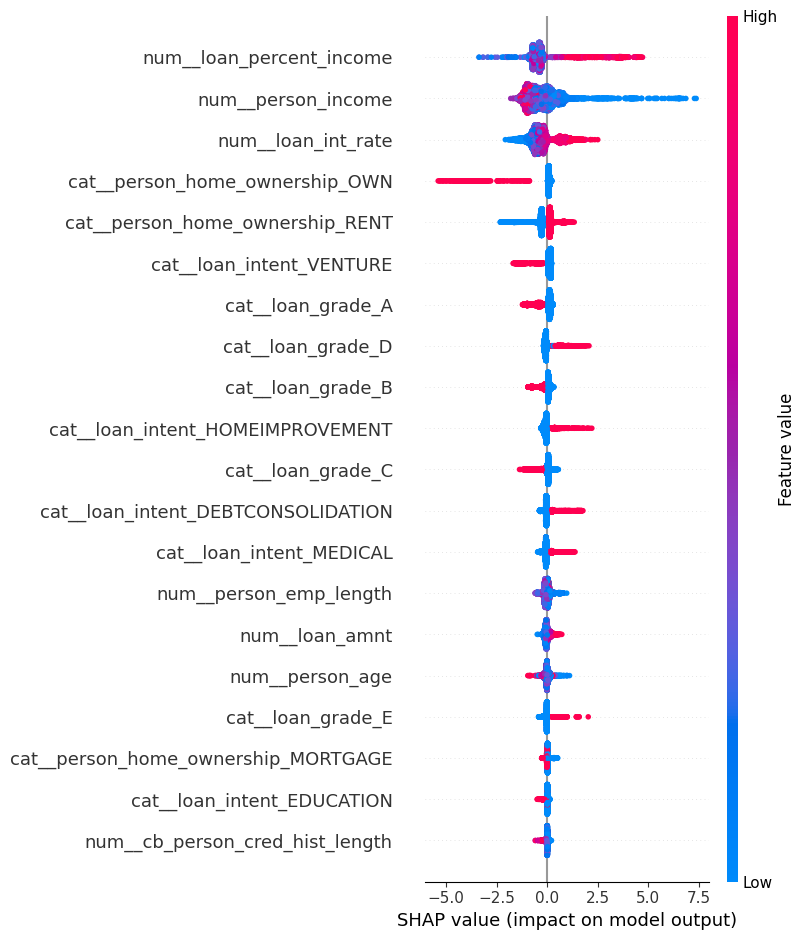

In [55]:
shap.summary_plot(shap_values, X_test_df)


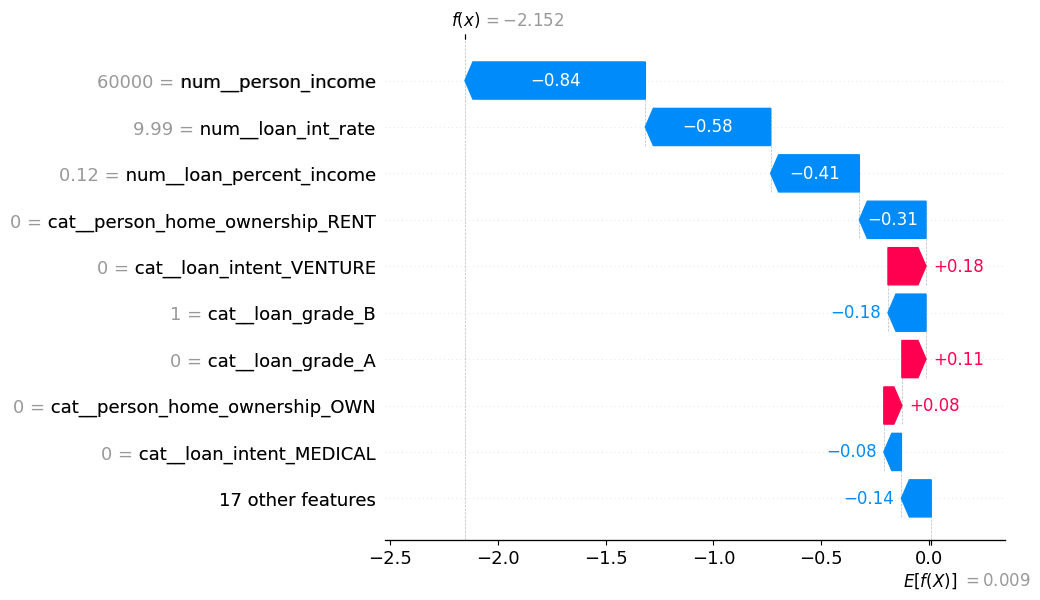

In [56]:

# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

In [57]:
y_pred = random_search.predict(X_test)


In [58]:

#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [59]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [60]:

print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")


False Positive : 246
False Negative : 259


In [61]:

import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [62]:
joblib.dump(best_threshold, "best_threshold.pkl")


['best_threshold.pkl']